## Auto_Correlation Analysis of 2D Square Lattice Ferromagnetic Ising Model

In [1]:
include("../src/lattice.jl")
include("../src/metropolis_ising.jl")
using .UnitCell_Lattices
using .Metropolis_MonteCarlo

using Plots
using StatsBase
using StatsPlots

In [2]:
J = 1.0
a = 1.0
h = 0.0
L = [16,16]
T = 0.2:0.2:3.0

0.2:0.2:3.0

In [3]:
A = [1.0 0.0;
     0.0 1.0] # Lattice vectors for a triangular lattice

B = [0.0;
     0.0]

B = reshape(B, (2,1))
     
uc_square = UnitCell(A,B)
rules_square = [    BondRule(1,1,[1,0]),
    BondRule(1,1,[0,1])]

2-element Vector{BondRule}:
 BondRule(1, 1, [1, 0])
 BondRule(1, 1, [0, 1])

In [4]:
data_22 = []
data_eq = []
data_29 = []
for Temp in [2.2, 2.27, 2.9]
    for n in 1:1
        lat = build_lattice(uc_square, rules_square, L)
        for site in lat.sites
            site.spin = [0, 0, rand(-1:2:1)]
        end
        res = monte_carlo_simulation(lat, Temp, J, h, 500000, 5000, 50)
        if Temp == 2.2
            push!(data_22, res)
        elseif Temp == 2.27
            push!(data_eq, res)
        else
            push!(data_29, res)
        end
    end
end

In [5]:
function autocorrelation(Q::Vector{Float64}, max_lag::Int)
    N = length(Q)
    Q_mean = mean(Q)
    Q_var = mean((Q .- Q_mean).^2)

    A = zeros(Float64,max_lag+1)
    for t in 0:max_lag
        s = 0
        c = N-t
        for i in 1:c
            s += Q[i+t]*Q[i]
        end
        mean_s = s/c
        A[t+1] = (mean_s - Q_mean)/Q_var
    end 
    return A
end

autocorrelation (generic function with 1 method)

In [6]:
m_22 = Float64[]
e_22 = Float64[]
m_sq_22 = Float64[]
for i in 1:length(data_22)
    append!(m_22,data_22[i][2])
    append!(e_22,data_22[i][1])
    append!(m_sq_22,data_22[i][3])
end

m_eq = Float64[]
e_eq = Float64[]
m_sq_eq = Float64[]
for i in 1:length(data_eq)
    append!(m_eq,data_eq[i][2])
    append!(e_eq,data_eq[i][1])
    append!(m_sq_eq,data_eq[i][3])
end

m_29 = Float64[]
e_29 = Float64[]
m_sq_29 = Float64[]
for i in 1:length(data_29)
    append!(m_29,data_29[i][2])
    append!(e_29,data_29[i][1])
    append!(m_sq_29,data_29[i][3])
end


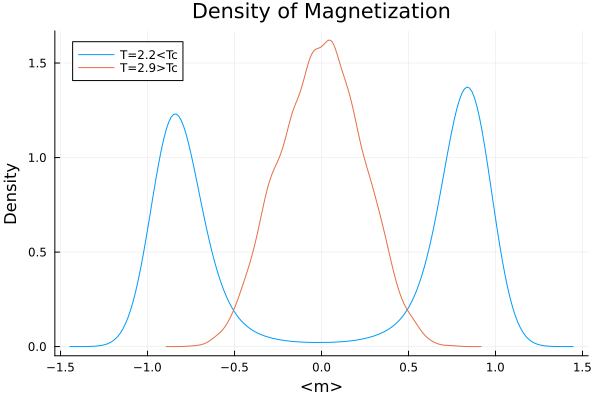

In [7]:
density(m_22,label="T=2.2<Tc",title="Density of Magnetization",xlabel="<m>",ylabel="Density")
density!(m_29,label="T=2.9>Tc")

In [8]:
max_lag = 500
A_m22 = autocorrelation(m_22,max_lag)
A_m29 = autocorrelation(m_29,max_lag)
A_meq = autocorrelation(m_eq,max_lag)

A_e22 = autocorrelation(e_22,max_lag)
A_e29 = autocorrelation(e_29,max_lag)
A_eeq = autocorrelation(e_eq,max_lag)

A_msq22 = autocorrelation(m_sq_22,max_lag)
A_msq29 = autocorrelation(m_sq_29,max_lag)
A_msqeq = autocorrelation(m_sq_eq,max_lag)

501-element Vector{Float64}:
 -4.020221986446544
 -4.789609823737056
 -4.943061784319511
 -5.008071403504646
 -5.022806848721785
 -5.018266236220919
 -5.0140722430089415
 -5.01687388620624
 -5.012734629691668
 -5.00863923364288
 -5.025146207216866
 -5.02804410372861
 -4.998594014044688
  ⋮
 -5.031736362613055
 -5.019387026284808
 -5.00721594411912
 -5.005705433339758
 -5.022447748188923
 -5.000237512885331
 -5.009865682167914
 -5.038396221675815
 -5.029098516123323
 -5.008441782679496
 -4.999228778132767
 -5.012812849769799

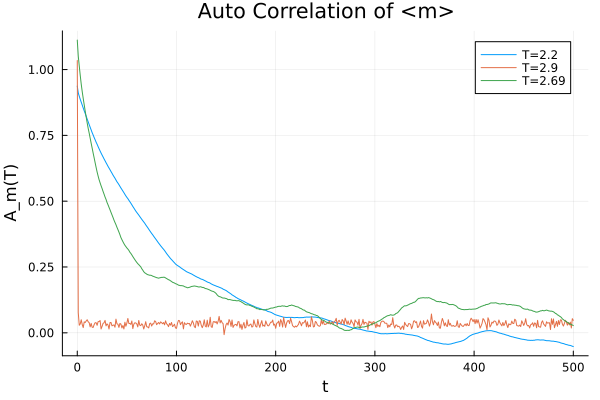

In [9]:

auto_cor_plot = plot(0:max_lag,A_m22,xlabel="t",ylabel="A_m(T)",title="Auto Correlation of <m>",label="T=2.2")
plot!(auto_cor_plot,0:max_lag,A_m29, label="T=2.9")
plot!(auto_cor_plot,0:max_lag,A_meq, label="T=2.69")

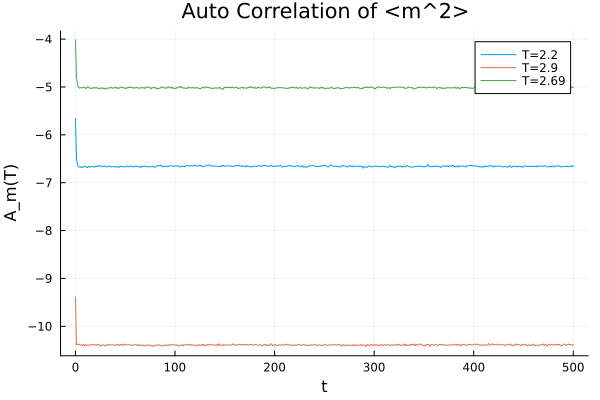

In [10]:
auto_cor_plot = plot(0:max_lag,A_msq22,xlabel="t",ylabel="A_m(T)",label="T=2.2",title="Auto Correlation of <m^2>")
plot!(auto_cor_plot,0:max_lag,A_msq29, label="T=2.9")
plot!(auto_cor_plot,0:max_lag,A_msqeq, label="T=2.69")

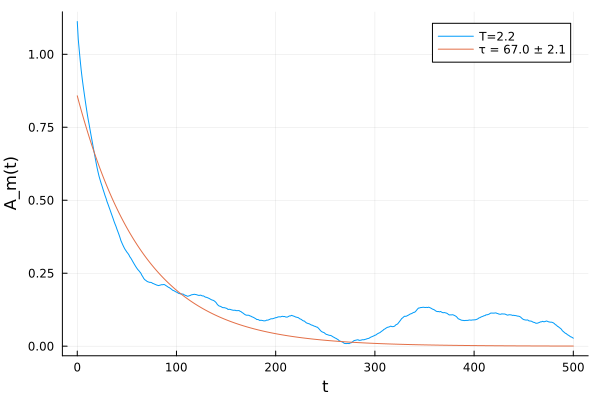

In [11]:
## correlation time
using LsqFit
A = A_meq
auto_correlation_model(t,p) = p[1].*exp.(-t./p[2])
t = collect(0:length(A)-1)
mask = A.>0.05 #eliminate the non-zero values
fit = curve_fit(auto_correlation_model,t[mask],A[mask],[1.0,10.0])
A0, τ = fit.param
A0_pm, τ_pm = standard_errors(fit)


p = plot(t, A,xlabel="t", ylabel="A_m(t)", label="T=2.2")
plot!(p,t,auto_correlation_model(t,[A0,τ]),label="τ = $(round(τ,sigdigits=2)) ± $(round(τ_pm,sigdigits=2))")



Q = 0.6536586623670028 ± 0.06413224148870367


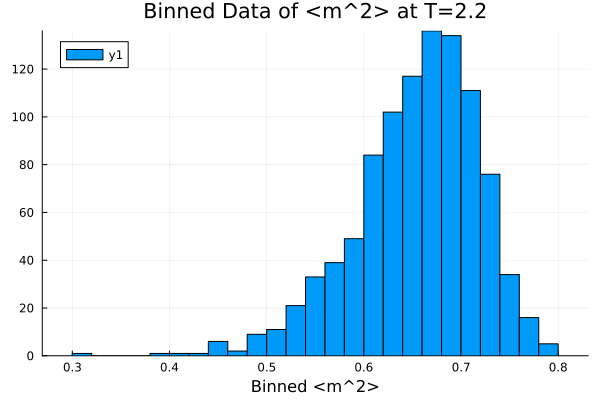

In [12]:
#Binning Data to estimate the error of the mean
function binning_data(data::Vector{Float64},bin_size::Int)
    data_binned = []
    for i in bin_size:bin_size:length(data)-bin_size
        push!(data_binned,data[i:i+bin_size])
    end

    B = length(data)
    B_data = []
    for i in 1:length(data_binned)
        mi = mean(data_binned[i])
        push!(B_data,mi)
    end

    B_mean = mean(B_data)
    B_std = sqrt(mean(B_data.^2) - B_mean^2)
    
    return B_mean, B_std, B_data
end
    
Binned = binning_data(m_sq_22,10)
println("Q = $(Binned[1]) ± $(Binned[2])")
histogram(Binned[3],xlabel="Binned <m^2>",title="Binned Data of <m^2> at T=2.2")